# Basic comparsion of naive and fast convolution

In [108]:
import numpy as np
import sympy as sy
from PIL import Image
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [109]:
from sympy.physics.quantum import TensorProduct

In [110]:
from fast_convolution.naive import naive_convolve
from fast_convolution.fast import toomcook_conv1d, toom_cook, g_to_bg
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

import fast_convolution as fast

In [111]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

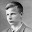

In [112]:
image = Image.open('../images/karatsuba032.jpg')
image

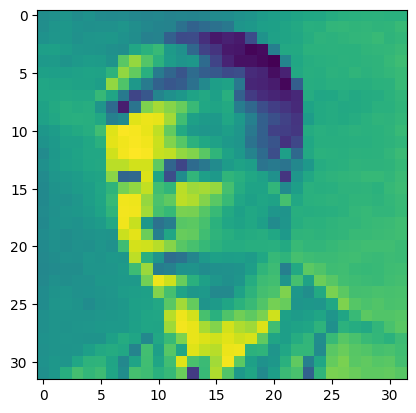

In [113]:
plt.imshow(image)

In [114]:
feature = np.array(image)
feature.shape

In [115]:
# Laplace discrete operator #
weight = np.array([
    [ 0, 1, 0],
    [ 1, -4, 1],
    [ 0, 1, 0],
])
weight

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [116]:
wr = weight[::-1, ::-1]
wr

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

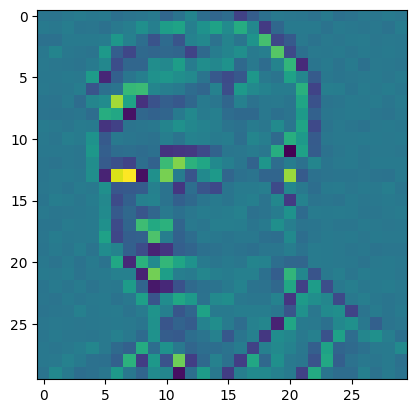

In [117]:
output = signal.convolve2d(feature, wr, mode='valid')
plt.imshow(output)

In [118]:
output[:5, :5]

array([[ -8, -10,  -2,  10,  -1],
       [  6,  -1,  16,  -8,  -7],
       [-19, -19,   5,   8,   7],
       [  0,  33,   0,  -6, -10],
       [  2,  -4,  -6, -10,   8]])

Running naive convolution
9 multiplications and 8 aditions per output scalar

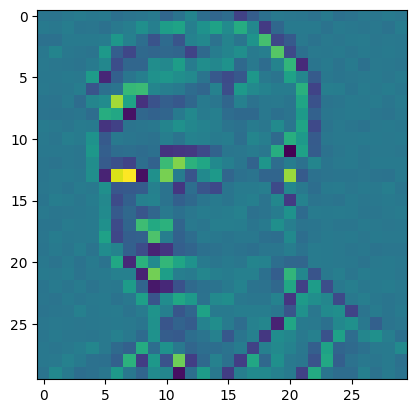

In [119]:
output_naive = naive_convolve(feature, weight)
plt.imshow(output_naive)

In [120]:
np.all(output == output_naive)

True

In [121]:
data_small = feature[:3, :3]
data_small

array([[118, 120, 124],
       [119, 125, 127],
       [122, 126, 127]], dtype=uint8)

In [122]:
output_small = signal.convolve2d(data_small, wr)
output_small

array([[   0,  118,  120,  124,    0],
       [ 118, -233, -113, -249,  124],
       [ 119, -111,   -8, -132,  127],
       [ 122, -243, -130, -255,  127],
       [   0,  122,  126,  127,    0]])

In [123]:
data_big = feature[:5, :5]
data_big

array([[118, 120, 124, 118, 122],
       [119, 125, 127, 122, 120],
       [122, 126, 127, 121, 125],
       [135, 136, 133, 126, 125],
       [129, 131, 124, 130, 133]], dtype=uint8)

In [124]:
points = [0, -1, 1, -2, np.inf]
points

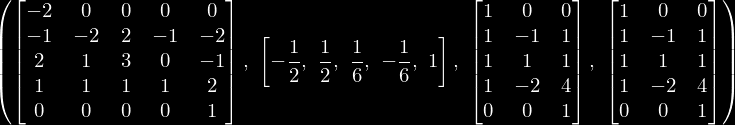

In [125]:
c1, cq1, b1, a1 = toom_cook(3, 3, points)
c1, cq1, b1, a1

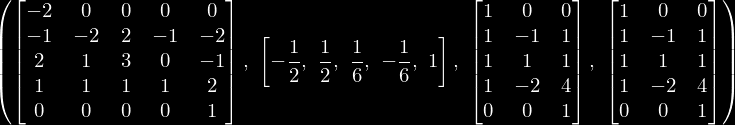

In [126]:
c2, cq2, b2, a2 = toom_cook(3, 3, points)
c2, cq2, b2, a2

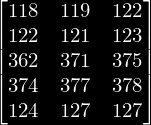

In [127]:
d1 = sy.Matrix([[a2*sy.Matrix(data_small[d]) for d in range(3)]])
d1

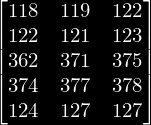

In [128]:
d1 = a2 * data_small.T
d1

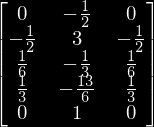

In [129]:
bg1 = sy.Matrix([[sy.diag(*cq2) * b2 * sy.Matrix(w) for w in weight]])
bg1

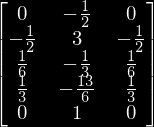

In [130]:
bg1 = sy.diag(*cq2) * b2 * sy.Matrix(weight.T)
bg1

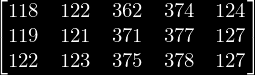

In [131]:
d1.T

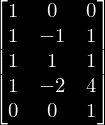

In [132]:
a1

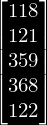

In [133]:
a1 * d1.T[::, 0]

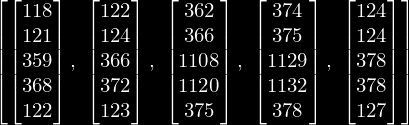

In [134]:
d2 = [a1 * d1.T[::, i] for i in range(5)]
# or #
# d2 = [a1 * sy.Matrix(d) for d in d1.tolist()] #
d2

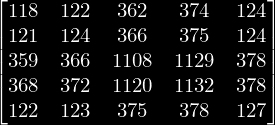

In [135]:
d2 = a1 * d1.T
d2

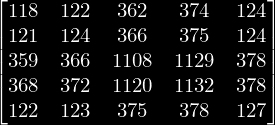

In [136]:
a1 * (a2 * data_small.T).T

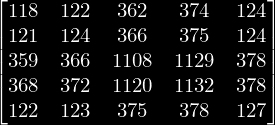

In [137]:
a1 * (a2 * data_small.T).T

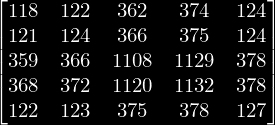

In [138]:
a1 * data_small * a2.T

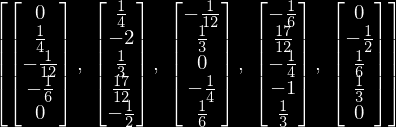

In [139]:
bg2 = [(sy.diag(*cq2) * b2) * bg1.T[::, i] for i in range(5)]
bg2

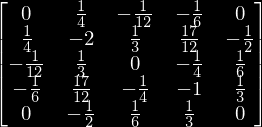

In [140]:
bg2 = (sy.diag(*cq2) * b2) * bg1.T
bg2

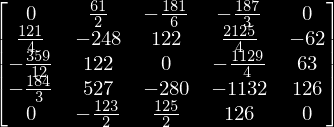

In [141]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

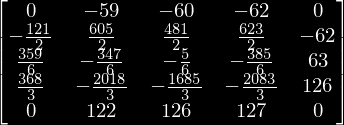

In [142]:
s1 = m * c1.T
s1

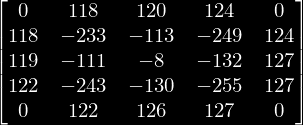

In [143]:
s2 = c2 * m * c1.T
s2

In [144]:
output_small

array([[   0,  118,  120,  124,    0],
       [ 118, -233, -113, -249,  124],
       [ 119, -111,   -8, -132,  127],
       [ 122, -243, -130, -255,  127],
       [   0,  122,  126,  127,    0]])

In [145]:
np.array(s2) == output_small

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

In [146]:
# sy.MatMul(a0.T, bg0, c0.T, sy.Matrix(feature[0, :5])) #

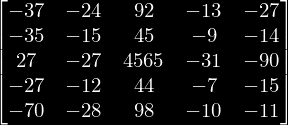

In [147]:
d2 = c1.T * data_big * c2
d2

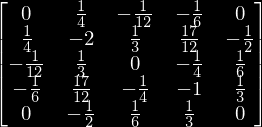

In [148]:
bg2 = (sy.diag(*cq2) * b2) * sy.Matrix(weight) * (sy.diag(*cq1) * b1).T
bg2

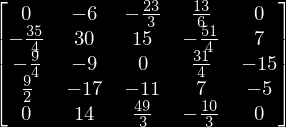

In [149]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

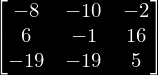

In [150]:
s = a1.T * m * a2
s

In [151]:
np.array(s) == output[:3, :3]

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

Lets try with tensor product

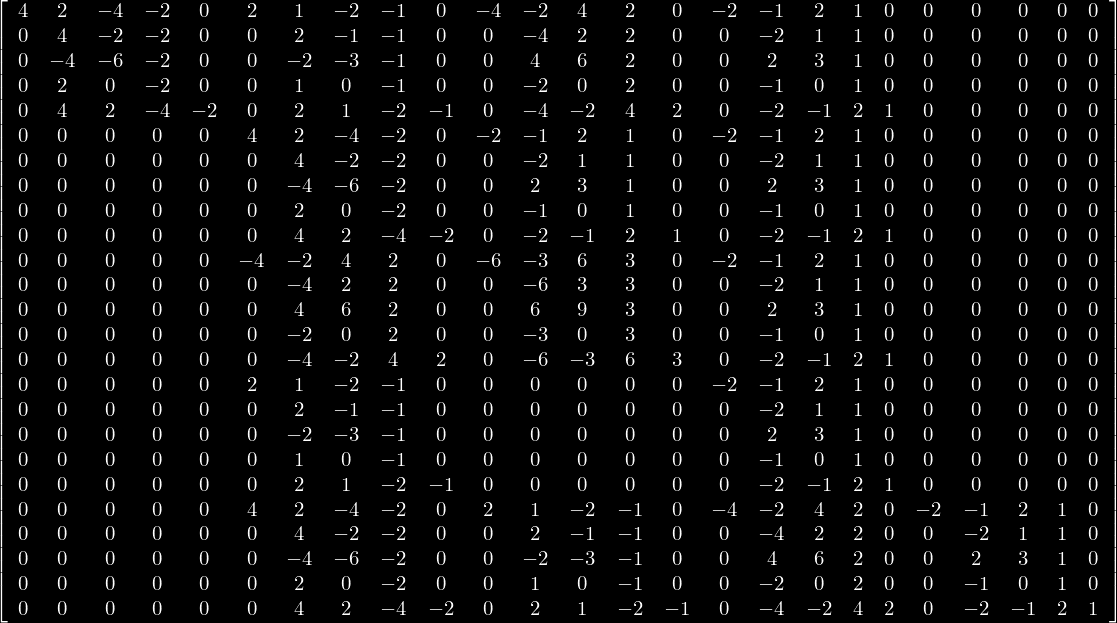

In [152]:
dt = TensorProduct(c1.T, c2.T)
# or #
# dt = TensorProduct(c1, c2).T #
dt

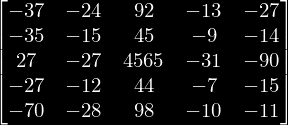

In [153]:
d2 = (dt * sy.Matrix(data_big.reshape(-1))).reshape(5, 5)
d2

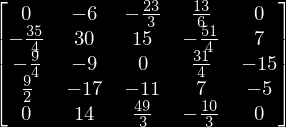

In [154]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

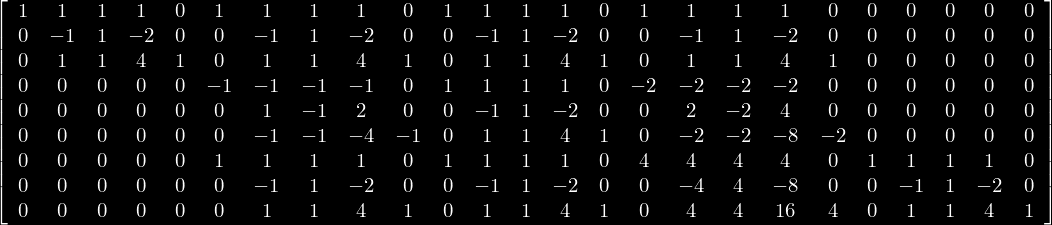

In [155]:
at = TensorProduct(a1, a2).T
at

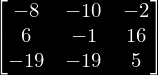

In [156]:
s = (at * sy.Matrix(np.array(m).reshape(-1))).reshape(3, 3)
s

Try 1.5D

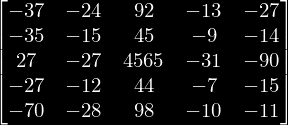

In [157]:
d2 = c1.T * data_big * c2
d2

basic quantization

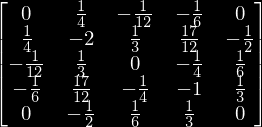

In [158]:
bg2 = (sy.diag(*cq2) * b2) * sy.Matrix(weight) * (sy.diag(*cq1) * b1).T
bg2